# LTE Italy Project Import and Ray-Tracing
This notebook imports the latest project exported from the GUI, configures the scene, and adds real-world Base Stations (BS).

In [1]:
import json
import os
from pathlib import Path
import numpy as np
from pyproj import Transformer
import xml.etree.ElementTree as ET
import sionna
from sionna.rt import load_scene, Transmitter, Receiver, PlanarArray, PathSolver, Camera

# Keep True in VS Code to avoid widget/controller instability with interactive preview
no_preview = True # Set False only if preview widget is stable in your environment
custom_dir = "/home/pguidetti/sionna/thesis/LTE-italy-SionnaExportTool/simple_scene/gaeaulenti_514807.76875415724_5036690.572493563/"
manual_dir = False #put to True to use the custom_dir instead of auto-discovery of the latest project folder

# 1. Auto-discovery of the latest project exported from the GUI
BASE_DIR = Path.cwd()
SIMPLE_SCENE_DIR = BASE_DIR / "simple_scene"

if not SIMPLE_SCENE_DIR.exists():
    raise FileNotFoundError("'simple_scene' folder not found. Please export a project from the GUI first.")

# Find the most recently modified project folder
project_folders = [d for d in SIMPLE_SCENE_DIR.iterdir() if d.is_dir()]
if not project_folders:
    raise FileNotFoundError("No projects found in 'simple_scene'.")

if manual_dir == False:
    # Sort by modification time (most recent last)
    LATEST_PROJECT_DIR = max(project_folders, key=os.path.getmtime)
else:
    #or change manually to a specific project folder
    LATEST_PROJECT_DIR = Path(custom_dir)  # Example: specify a project folder directly

# Look for required files in the folder
XML_SCENE = LATEST_PROJECT_DIR / "simple_OSM_scene.xml"
JSON_FILES = list(LATEST_PROJECT_DIR.glob("*.json"))

if not XML_SCENE.exists():
    raise FileNotFoundError(f"Could not find XML scene in {LATEST_PROJECT_DIR}")

# Default project values to allow running even without JSON
project = {
    "utm_epsg": "EPSG:32633",
    "center": {"lat": 0.0, "lon": 0.0},
    "transmitters": []
}
has_project_json = False

# Try JSON in project folder first, fallback to root legacy file
JSON_FILE = JSON_FILES[0] if JSON_FILES else None
if JSON_FILE is None:
    legacy_json = BASE_DIR / "Sionna_Project_1.json"
    if legacy_json.exists():
        JSON_FILE = legacy_json

if JSON_FILE is not None:
    try:
        with open(JSON_FILE, "r") as f:
            project = json.load(f)
        has_project_json = True
    except Exception as json_error:
        print(f"⚠ JSON found but not readable ({json_error}). Continuing without BS import.")

print(f"✓ Detected Project: {LATEST_PROJECT_DIR.name}")
print(f"✓ XML Scene: {XML_SCENE.name}")
if has_project_json:
    print(f"✓ JSON Loaded: {Path(JSON_FILE).name}")
else:
    print("⚠ No JSON found. Continuing without BS import.")
print(f"✓ Detected EPSG: {project.get('utm_epsg', 'EPSG:32633')}")

✓ Detected Project: duomo_514904.1347483909_5034538.212385819
✓ XML Scene: simple_OSM_scene.xml
✓ JSON Loaded: duomo.json
✓ Detected EPSG: EPSG:32632


### Coordinate Transformation Configuration
We use the EPSG saved by the GUI to ensure correct metric distances.

In [2]:
# Read EPSG from JSON or use default
target_epsg = project.get('utm_epsg', "EPSG:32633")
wsg84 = "EPSG:4326"

if not isinstance(target_epsg, str) or not target_epsg.strip():
    raise ValueError(f"Invalid EPSG in project JSON: {target_epsg}")

transformer = Transformer.from_crs(wsg84, target_epsg, always_xy=True)

# Calculate scene center in meters
center_gps = project.get('center', None)
if isinstance(center_gps, dict) and 'lon' in center_gps and 'lat' in center_gps:
    center_m = transformer.transform(center_gps['lon'], center_gps['lat'])
else:
    center_m = (0.0, 0.0)
    print("⚠ JSON center not available. Using scene origin as fallback center.")

def gps_to_sionna(lon, lat, height=30.0):
    """Converts GPS to [x, y, z] relative to the scene center."""
    pos_m = transformer.transform(lon, lat)
    x = pos_m[0] - center_m[0]
    y = pos_m[1] - center_m[1]
    return [float(x), float(y), float(height)]

### Scene Loading and BS Placement

2026-04-24 08:11:09 WARN  [HDRFilm] Monochrome mode enabled, setting film output pixel format to 'luminance' (was rgb).
Added BS_14 at -169.5m, -9.9m
Added BS_31 at -167.5m, -19.8m
Added BS_32 at -178.3m, -85.8m
Added BS_33 at 144.5m, 49.6m
Added BS_22 at 45.0m, -43.7m
Added BS_31_1 at 25.8m, -57.2m
Added BS_21 at -172.9m, 47.9m
Added BS_21_1 at -76.0m, -0.2m
Added BS_21_2 at -77.5m, -0.2m
Added BS_31_2 at -77.2m, -0.3m

✓ Scene successfully loaded with 10 BS.
no_preview=True: generating static render instead of interactive preview.


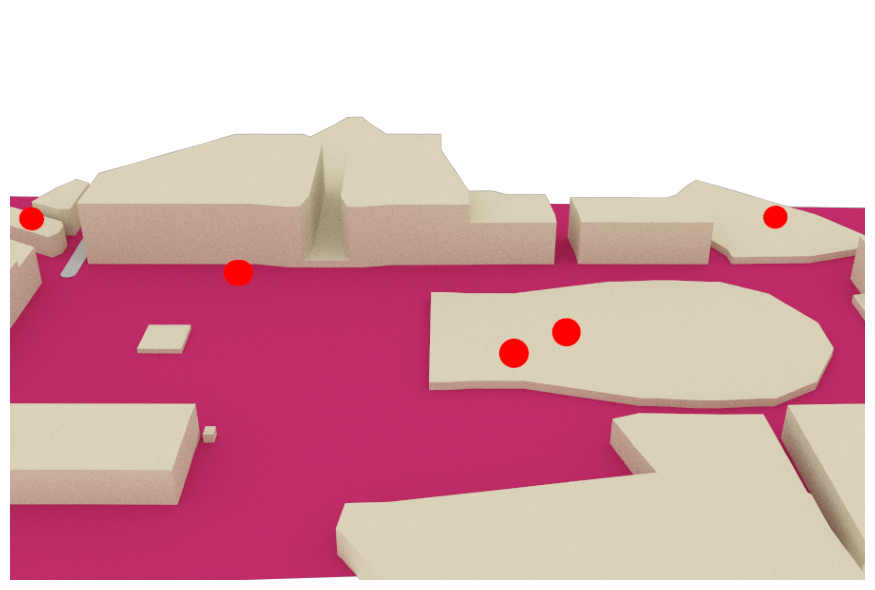

In [3]:
scene = None
try:
    # Validate mesh references declared in XML before loading the scene
    xml_root = ET.parse(XML_SCENE).getroot()
    missing_meshes = []
    for shape_node in xml_root.findall(".//shape[@type='ply']"):
        filename_node = shape_node.find("string[@name='filename']")
        if filename_node is None:
            continue
        mesh_rel_path = filename_node.attrib.get("value", "")
        mesh_abs_path = XML_SCENE.parent / mesh_rel_path
        if not mesh_abs_path.exists():
            missing_meshes.append(str(mesh_abs_path))

    if missing_meshes:
        raise FileNotFoundError(
            "Missing mesh files referenced by XML:\n" + "\n".join(missing_meshes[:10])
        )

    # Load XML scene (mesh paths are relative to the XML)
    scene = load_scene(str(XML_SCENE.resolve()))
    
    # Clear any default transmitters
    for tx_name in list(scene.transmitters.keys()):
        scene.remove(tx_name)

    def unique_bs_name(base_name):
        """Return a unique transmitter name by appending _1, _2, ... when needed."""
        if base_name not in scene.transmitters:
            return base_name
        suffix = 1
        while f"{base_name}_{suffix}" in scene.transmitters:
            suffix += 1
        return f"{base_name}_{suffix}"

    # Add BS from JSON only if available
    if has_project_json and project.get('transmitters'):
        for bs in project['transmitters']:
            base_name = f"BS_{bs['CID']}"
            tx_name = unique_bs_name(base_name)
            pos = gps_to_sionna(bs['Lon'], bs['Lat'])

            tx = Transmitter(name=tx_name, position=pos, display_radius=5.0)
            scene.add(tx)
            print(f"Added {tx_name} at {pos[0]:.1f}m, {pos[1]:.1f}m")
    else:
        print("⚠ No JSON found. Skipping BS import.")

    # Default antenna arrays
    scene.tx_array = PlanarArray(num_rows=1, num_cols=1, pattern="dipole", polarization="V")
    scene.rx_array = PlanarArray(num_rows=1, num_cols=1, pattern="dipole", polarization="V")

    print(f"\n✓ Scene successfully loaded with {len(scene.transmitters)} BS.")

    if no_preview:
        print("no_preview=True: generating static render instead of interactive preview.")
        static_cam = Camera(position=[0, -350, 220], look_at=[0, 0, 20])
        scene.render(camera=static_cam, resolution=[900, 600], num_samples=128)
    else:
        try:
            scene.preview()
        except Exception as preview_error:
            print(f"Preview failed ({preview_error}); falling back to static render.")
            static_cam = Camera(position=[0, -350, 220], look_at=[0, 0, 20])
            scene.render(camera=static_cam, resolution=[900, 600], num_samples=128)
except Exception as e:
    print(f"✗ Error: {e}")
    raise

✓ Added receiver 'UE_center' at [0, 0, 1.5] m
✓ Ray tracing completed. Total active paths (max per link): 12


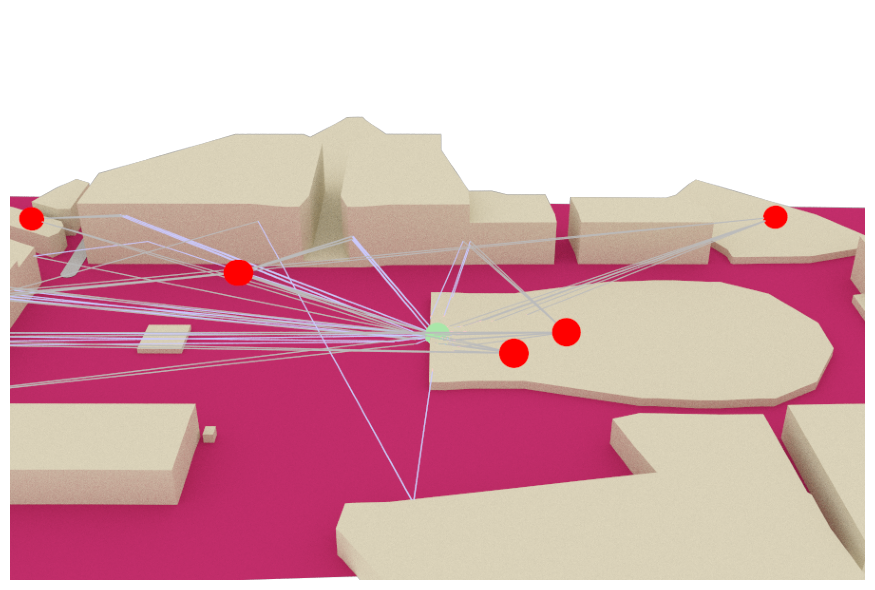

In [4]:
# 4. Add one UE at map center and run ray tracing
if scene is None:
    raise RuntimeError("Scene not loaded. Run Cell 6 first.")

ue_name = "UE_center"
if ue_name in scene.receivers:
    scene.remove(ue_name)

# Scene coordinates are centered on the selected area, so center is [0,0]
ue = Receiver(name=ue_name, position=[0.0, 0.0, 1.5], display_radius=5.0)
scene.add(ue)

# Point every transmitter toward the center UE
for tx_obj in scene.transmitters.values():
    tx_obj.look_at(ue)

p_solver = PathSolver()
paths = p_solver(
    scene=scene,
    max_depth=3,
    los=True,
    specular_reflection=True,
    diffuse_reflection=False,
    refraction=True,
    synthetic_array=True,
    seed=42,
    )

# Count valid paths in a version-compatible way
_, tau = paths.cir(normalize_delays=True, out_type="numpy")
valid_entries = np.isfinite(tau) & (tau >= 0)
num_paths = int(np.max(np.sum(valid_entries, axis=-1)))

print(f"✓ Added receiver '{ue_name}' at [0, 0, 1.5] m")
print(f"✓ Ray tracing completed. Total active paths (max per link): {num_paths}")

if no_preview:
    cam_rt = Camera(position=[0, -350, 220], look_at=[0, 0, 20])
    scene.render(camera=cam_rt, paths=paths, resolution=[900, 600], num_samples=128)
else:
    try:
        scene.preview(paths=paths, clip_at=250)
    except Exception as preview_error:
        print(f"Preview failed ({preview_error}); showing static render.")
        cam_rt = Camera(position=[0, -350, 220], look_at=[0, 0, 20])
        scene.render(camera=cam_rt, paths=paths, resolution=[900, 600], num_samples=128)

In [5]:
scene.preview(paths=paths, clip_at=250)